# Multivariable Regression with Scikit-learn  
# diamond-price-prediction
A supervised machine learning project that predicts diamond prices using regression techniques. The model is trained on the classic Diamonds dataset (53,940 samples) and leverages both numerical and categorical features to produce accurate price estimates.
# Diamond Data
This classic dataset contains the prices and other attributes of almost 54,000 diamonds. 
# Data Link
https://www.kaggle.com/datasets/shivam2503/diamonds

# Data Dictionary

- price: price in US dollars (\$326--\$18,823)
- carat : weight of the diamond (0.2--5.01)
- cut : quality of the cut (Fair, Good, Very Good, Premium, Ideal)
- color : diamond colour, from J (worst) to D (best)
- clarity: a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
- x :length in mm (0--10.74)
- y :width in mm (0--58.9)
- z :depth in mm (0--31.8)
- depth :total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
- table: width of top of diamond relative to widest point (43--95)

In [2]:
# import libraries
import pandas as pd                     # for loading and working with data tables
import numpy as np
import matplotlib.pyplot as plt        # for plotting graphs
import seaborn as sns
from sklearn.model_selection import train_test_split   # to split data into training and testing sets
from sklearn.preprocessing import StandardScaler, OneHotEncoder      # to scale features and convert categorical features
from sklearn.linear_model import LinearRegression      # linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
# functions to evaluate the model

plt.rcParams["figure.figsize"] = (7, 4)   # set default figure size
plt.rcParams["axes.grid"] = True          # show grid on plots

In [3]:
# load data
df = pd.read_csv("diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# Inspect the data

In [4]:
# get information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
# show statical information about numeric data
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
# show statical information about categoric data
df.describe(include='object')

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


# Clean the data

In [7]:
df.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# Explore the data

<Axes: xlabel='cut', ylabel='count'>

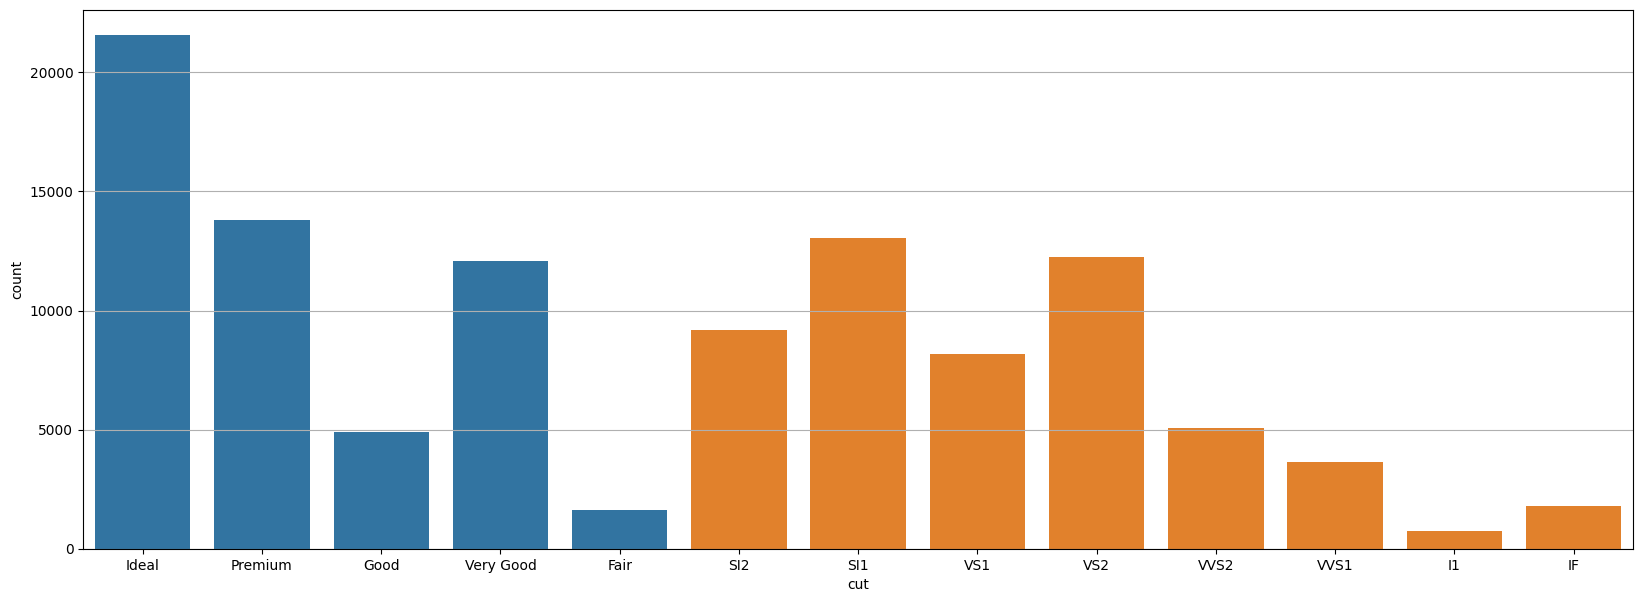

In [10]:
fig, ax = plt.subplots( figsize=(20, 7)) 
sns.countplot(data=df,x='cut' )
sns.countplot(data=df,x='clarity' )

Text(0.5, 1.0, 'Table vs price')

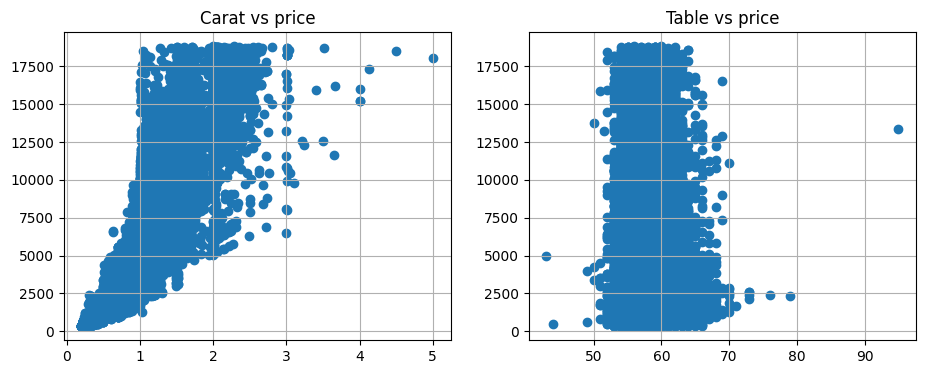

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))  
ax[0].scatter(data=df,x='carat' ,y='price')
ax[0].set_title("Carat vs price")  

ax[1].scatter(data=df,x='table' ,y='price')
ax[1].set_title("Table vs price") 

In [12]:
# define features and Target
# drop Unnamed: 0 
# Use np.log to Compress the skewed distribution into a normal-like shape. Makes cheap and expensive diamonds equally influential. Eliminates the negative prediction problem.
X = df.drop(columns=["price", "Unnamed: 0"], axis=1)
y = np.log(df["price"])

In [13]:
# split data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1 )

## Feature Scaling for numeric Features

In [14]:
# define numeric features and object features
num_cols = X_train.select_dtypes("number").columns

# feature scaling 
scaler = StandardScaler()  

# Instantiate the pipeline
num_pipe = make_pipeline(scaler)

# Make the tuple for ColumnTransformer
num_tuple = ('numeric',num_pipe,num_cols)
num_tuple


('numeric',
 Pipeline(steps=[('standardscaler', StandardScaler())]),
 Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object'))

## One Hot Encoder for categorical Features

In [15]:
# Create the preprocessing pipeline for categorical data
cat_selector =  X_train.select_dtypes('object').columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_pipe = make_pipeline(ohe)

cat_tuple = ('categorical',cat_pipe, cat_selector)
cat_tuple

('categorical',
 Pipeline(steps=[('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['cut', 'color', 'clarity'], dtype='object'))

In [16]:

# Create the preprocessing ColumnTransformer
preprocessor = ColumnTransformer([cat_tuple, num_tuple],
verbose_feature_names_out=False)

preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['cut', 'color', 'clarity'], dtype='object')),
                                ('numeric',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object'))],
                  verbose_feature_names_out=False)

In [17]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['cut', 'color', 'clarity'], dtype='object')),
                                ('numeric',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object'))],
                  verbose_feature_names_out=False)

In [18]:
x_train_transformed=preprocessor.transform(X_train)
x_test_transformed=preprocessor.transform(X_test)

In [19]:
# Train the model
model = LinearRegression()
# create a linear regression model

model.fit(x_train_transformed, y_train)
# train the model using training data (learn weights and bias)

LinearRegression()

In [20]:
# Show coefficients
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [-0.09677521 -0.00545001  0.05927237  0.01455302  0.02839982  0.21078573
  0.15055007  0.12139348  0.05312026 -0.04674467 -0.17398725 -0.31511762
 -0.71071885  0.38843661 -0.09799193 -0.26602218  0.11202223  0.04482898
  0.29763943  0.23180571 -0.27294059  0.07386862  0.02008387  1.30089403
  0.03252997  0.02506259]
Bias: 7.704067364564181


In [21]:
# use np.exp to Convert log predictions back to real dollar prices. Since e^x is always positive, negative predictions become mathematically impossible.
# prdicted vs. Actual
y_pred = model.predict(x_test_transformed)
# use the trained model to make predictions
y_pred_actual = np.exp(y_pred)
results = pd.DataFrame({
    "Actual Price":  np.exp(y_test.values),     # real prices
    "Predicted Price": y_pred_actual         # predicted prices
})

results.head(10)


,Actual Price,Predicted Price
0,564.0,543.057002
1,5914.0,5911.361313
2,2562.0,2648.990411
3,537.0,620.024834
4,5964.0,5974.337305
5,984.0,1258.839626
6,5247.0,5156.860207
7,611.0,689.698494
8,9645.0,9842.827331
9,1162.0,1112.987066


# Evaluate the model

In [22]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)  
# average difference between real and predicted values

rmse = mean_squared_error(y_test, y_pred) ** 0.5  
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_test, y_pred)  
# how well the model fits the data (closer to 1 is better)

# print results
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

MAE  = 0.111
RMSE = 0.158
R^2  = 0.975


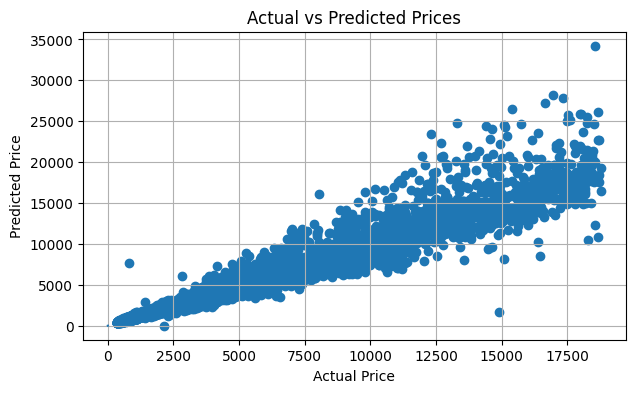

In [23]:
# Visualize model with real data

plt.scatter(np.exp(y_test.values), y_pred_actual )  
# plot actual values vs predicted values (each point = one house)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])  
# draw diagonal line (perfect prediction line)

plt.title("Actual vs Predicted Prices")  
# title of the graph

plt.xlabel("Actual Price")  
# x-axis: real prices

plt.ylabel("Predicted Price")  
# y-axis: predicted prices

plt.show()  
# display the graph

# Buiding xgboost

In [45]:
# Train the XGBoost Regressor with tuning and early stopping
from xgboost import XGBRegressor


# Split data for validation (for early stopping)
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_transformed, y_train, test_size=0.2, random_state=42
)

# Create tuned XGBoost Regressor
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,  # Stop if no improvement after 50 rounds
    verbose=False
)

# Train the model with early stopping
model.fit(
    x_train_final, 
    y_train_final,
    eval_set=[(x_val, y_val)],  # Validation set for early stopping
    verbose=False
)



C:\Users\sa\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:52:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "verbose" } are not used.

  self.starting_round = model.num_boosted_rounds()


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [25]:
# use np.exp to Convert log predictions back to real dollar prices. Since e^x is always positive, negative predictions become mathematically impossible.
# prdicted vs. Actual
y_pred = model.predict(x_test_transformed)
# use the trained model to make predictions
y_pred_actual = np.exp(y_pred)
results = pd.DataFrame({
    "Actual Price":  np.exp(y_test.values),     # real prices
    "Predicted Price": y_pred_actual         # predicted prices
})

results.head(10)

,Actual Price,Predicted Price
0,564.0,489.880707
1,5914.0,5618.245605
2,2562.0,2607.157715
3,537.0,509.088623
4,5964.0,6026.934082
5,984.0,1205.336792
6,5247.0,5072.550781
7,611.0,650.483826
8,9645.0,10911.006836
9,1162.0,1018.329346


In [28]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)  
# average difference between real and predicted values

rmse = mean_squared_error(y_test, y_pred) ** 0.5  
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_test, y_pred)  
# how well the model fits the data (closer to 1 is better)

# print results
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

MAE  = 0.061
RMSE = 0.084
R^2  = 0.993


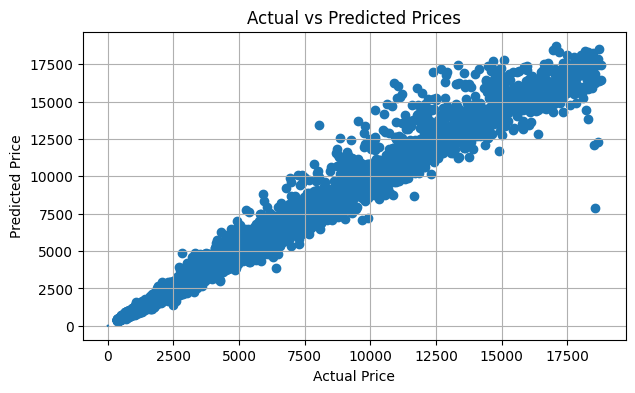

In [42]:
# Visualize model with real data

plt.scatter(np.exp(y_test.values), np.exp(y_pred) )  
# plot actual values vs predicted values (each point = one house)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])  
# draw diagonal line (perfect prediction line)

plt.title("Actual vs Predicted Prices")  
# title of the graph

plt.xlabel("Actual Price")  
# x-axis: real prices

plt.ylabel("Predicted Price")  
# y-axis: predicted prices

plt.show()  
# display the graph

# Predict on new data

In [26]:
# Step1 : Create a new dataframe to test the model
new_diamonds = pd.DataFrame({
    'carat':   [0.5,   1.2,   2.0  ],
    'cut':     ['Ideal', 'Premium', 'Good'],
    'color':   ['E',   'G',   'J'  ],
    'clarity': ['VS1', 'SI1', 'I1' ],
    'depth':   [61.5,  59.8,  63.0 ],
    'table':   [55.0,  58.0,  60.0 ],
    'x':       [5.09,  6.82,  8.12 ],
    'y':       [5.12,  6.79,  8.08 ],
    'z':       [3.14,  4.06,  5.10 ]
})

print("New Diamond Samples:")
print(new_diamonds)
print()


New Diamond Samples:
   carat      cut color clarity  depth  table     x     y     z
0    0.5    Ideal     E     VS1   61.5   55.0  5.09  5.12  3.14
1    1.2  Premium     G     SI1   59.8   58.0  6.82  6.79  4.06
2    2.0     Good     J      I1   63.0   60.0  8.12  8.08  5.10



In [44]:
# Step 2: Transform using your preprocessor (encodes strings to numbers)
new_diamonds_transformed = preprocessor.transform(new_diamonds)

# Step 3: Predict using your model
y_pred_log = model.predict(new_diamonds_transformed)

# Step 4: Convert log back to real prices
y_pred_actual = np.exp(y_pred_log)

# Step 5: Show results
results = pd.DataFrame({
    'Carat':               new_diamonds['carat'].values,
    'Cut':                 new_diamonds['cut'].values,
    'Color':               new_diamonds['color'].values,
    'Clarity':             new_diamonds['clarity'].values,
    'Predicted Price ($)': np.round(y_pred_actual, 2)
})

print(results)

   Carat      Cut Color Clarity  Predicted Price ($)
0    0.5    Ideal     E     VS1          1789.380005
1    1.2  Premium     G     SI1          6139.609863
2    2.0     Good     J      I1          6191.959961


# Conclusion

Through analyzing the model's coefficients, we can conclude that each feature has an effect on the target variable (price), but to varying degrees. Some features influence the price positively, while others have a negative impact.
The predicted prices are close to the actual prices, which indicates that the model is performing well and has learned the underlying patterns in the data.
The biggest challenge I faced during model building was the appearance of negative predicted prices, which is physically impossible for diamond pricing. After researching the issue, I found that applying np.log() on the target variable during training and then using np.exp() to convert predictions back to real prices was an effective solution. This approach eliminated all negative predictions and resulted in significantly better results.
Finally, while the model performs reasonably well, there is still room for improvement. Feature engineering could be a strong next step — creating new meaningful features from the existing ones such as volume (x * y * z) or carat-to-depth ratio may help the model capture more complex relationships and improve prediction accuracy.